In [ ]:
# %load_ext autoreload
# %autoreload 2

In [1]:
# for google colab

!pip install pypose
!pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 124.3 MB/s eta 0:00:00


In [4]:
!unzip -q /content/drive/MyDrive/SonarOdometryDataset/aracati2017.zip -d /content/drive/MyDrive/SonarOdometryDataset/aracati2017

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
%cd /content/
!git clone https://github.com/MarcinJanis/SonarOdometry.git
%cd SonarOdometry


/content
Cloning into 'SonarOdometry'...
remote: Enumerating objects: 4077, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 4077 (delta 115), reused 68 (delta 35), pack-reused 3872 (from 2)
Receiving objects: 100% (4077/4077), 572.26 MiB | 27.53 MiB/s, done.
Resolving deltas: 100% (1368/1368), done.
/content/SonarOdometry


In [6]:
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F


import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

from box import Box
import yaml

import matplotlib.pyplot as plt
from tqdm import tqdm

import random
import time

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier
from src.data_loader.metrics import eval_metrics_2d


Ate: 1.2061317924511203, expected


In [7]:
# Path to root directory
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
root_dir = '/content/SonarOdometry'

# Configuration Files
model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

# Path to evaluation dataset
# data_root_dir = os.path.join(root_dir, 'SonarOdometryDataset/supervised/val/seq_14')
# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'
data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/aracati2017/aracati2017'


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])

# Import data generator
from src.data_loader.transforms import SonarDatasetTranforms

fls_resolution = (model_config.FLS_INPUT_HEIGHT, model_config.FLS_INPUT_WIDTH) # for own ds
fls_resolution = (model_config.ARACATI_FLS_INPUT_HEIGHT, model_config.ARACATI_FLS_INPUT_WIDTH) # for aracati

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = SonarDatasetTranforms, calibration = extrinsics_calib)
data_lenght = data_generator.get_len()

print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

# Import model
from src.models.odometry2d import sonar_odometry

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SonarOdometryDataset/aracati2017/sequence.csv'

In [ ]:
def visualize_loftr_matches(visu, num_matches=100):

    img = visu['combined_imgs']
    pts1 = visu['pts1']
    pts2 = visu['pts2']
    offset_x = visu['pts2_offset'][1]

    if len(pts1) == 0:
        print("Brak dopasowań do wyświetlenia!")
        return

    n = min(len(pts1), num_matches)
    indices = np.random.choice(len(pts1), n, replace=False)

    fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
    ax.imshow(img)

    for i in indices:
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]

        ax.plot([x1, x2 + offset_x], [y1, y2], color='cyan', linewidth=0.8, alpha=0.5)
        ax.plot(x1, y1, 'ro', markersize=3)
        ax.plot(x2 + offset_x, y2, 'go', markersize=3)

    ax.set_title(f'Matched points ({n}/{len(pts1)} points displayed)')
    ax.axis('off')
    plt.show()

Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /root/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:02<00:00, 15.7MB/s]


Init state: [ 1.0441172  -0.06401658], azimuth: -0.2866029819922351


Sonar odometry:  50%|█████     | 10/20 [00:16<00:15,  1.57s/it]

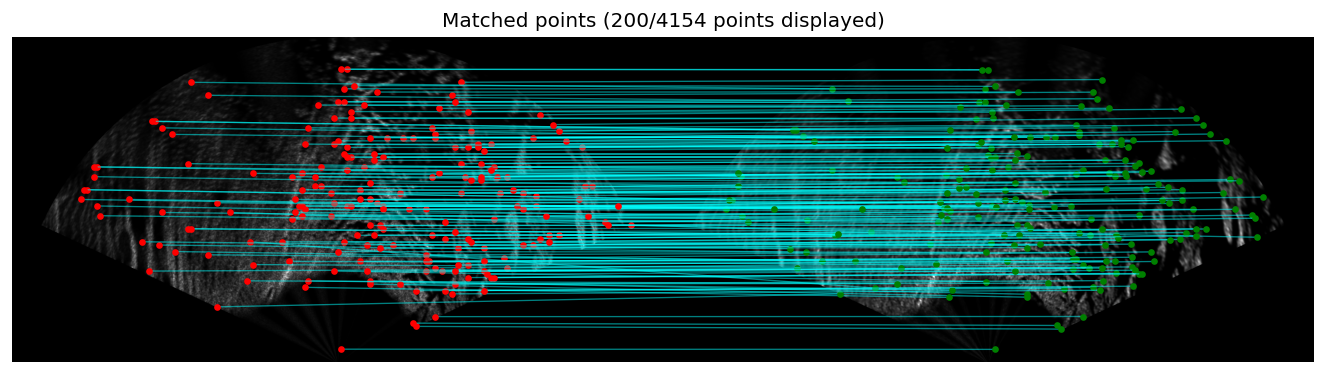

Sonar odometry:  55%|█████▌    | 11/20 [00:19<00:17,  1.99s/it]

Iter: 10. Frames: 10 + 12. Inliers: 1668/4154


Sonar odometry: 100%|██████████| 20/20 [00:34<00:00,  1.75s/it]


Metrics
Absolute trajectory error: 1.4354807847752145 [m]
Relative pose error: 0.2256994995205804 [m]


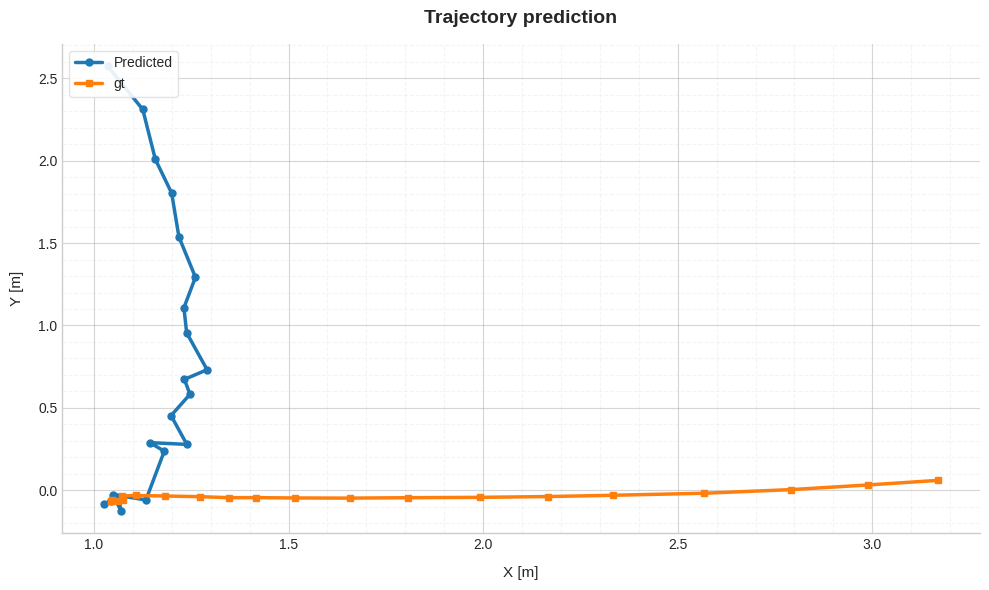

In [ ]:
model = sonar_odometry(model_config, sonar_config, device = device,
                       depth_compesation = True,
                       key_frames = True)


# seq 0: 0 -> 4811, (4811 samples)
# seq 1: 4811 -> 9622, (4811 samples)
# seq 2: 9624 -> 14435, (4813 samples)

start_idx = 0
max_iter = 30
stride = 1

# data containers
gt_xy = []
pred_xy = []

if hasattr(extrinsics_calib, 'se3_s2r') and isinstance(extrinsics_calib.se3_s2r, torch.Tensor) and extrinsics_calib.se3_s2r.device != device:
    extrinsics_calib.se3_s2r = extrinsics_calib.se3_s2r.to(device)
if hasattr(extrinsics_calib, 'se3_r2s') and isinstance(extrinsics_calib.se3_r2s, torch.Tensor) and extrinsics_calib.se3_r2s.device != device:
    extrinsics_calib.se3_r2s = extrinsics_calib.se3_r2s.to(device)


# set initial state
t, frame, pose_gt, depth = data_generator.get_sample(start_idx, return_visu=False, return_depth=True)

# init pose (x, y)
init_xy = pose_gt[0:2].detach().cpu().numpy()
gt_xy.append(pose_gt[0:2])
pred_xy.append(pose_gt[0:2].detach().cpu().numpy())

# init azimuth
rot = R.from_quat(pose_gt[3:7].detach().cpu().numpy())
euler = rot.as_euler('zyx', degrees=False)
init_azimuth = euler[0] # yaw
print(f'Init state: {init_xy}, azimuth: {init_azimuth}')

init_frame = frame.squeeze(1).to(device)

model.set_init_state(init_xy[0], init_xy[1], init_azimuth, init_frame)

# --- main loop ---

for i in tqdm(range(start_idx, start_idx + max_iter, stride), desc="Sonar odometry"):

    t, frame, pose_gt, depth = data_generator.get_sample(i, return_visu=False, return_depth=True)

    pred_pose, pred_azimuth = model(frame.squeeze(1).to(device), depth.to(device), return_visu = False)

    gt_xy.append(pose_gt[0:2])
    pred_xy.append(pred_pose)


gt_xy_np = torch.stack(gt_xy).cpu().numpy()
pred_xy_np = np.array(pred_xy)

# === visualise results ===

# --- metrics ---
ATE, RPE = eval_metrics_2d(pred_xy_np, gt_xy_np)

print('='*50)
print('Metrics')
print(f'Absolute trajectory error: {ATE} [m]')
print(f'Relative pose error: {RPE} [m]')
print('='*50)

# --- trajectory ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

ax.plot(pred_xy_np[:, 0], pred_xy_np[:, 1], label='Predicted', linewidth=2.5, marker='o', markersize=5)
ax.plot(gt_xy_np[:, 0], gt_xy_np[:, 1], label='gt', linewidth=2.5, marker='s', markersize=5)

ax.minorticks_on()
ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

ax.set_title('Trajectory prediction', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('X [m]', fontsize=11, labelpad=10)
ax.set_ylabel('Y [m]', fontsize=11, labelpad=10)

ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()

plt.show()